In [24]:
import pandas as pd
xls = pd.ExcelFile('/tscc/projects/ps-malilab/ydoctor/Ligandome_Screens/Fitness_Screen_Analysis/iPSC Ligand Fitness Screen Data.xlsx')
sheets = {sheet: xls.parse(sheet) for sheet in xls.sheet_names}
e6d14 = sheets['Day14_E6_vs_Day4_median.sgrna_s']
e6vsmtesrd14 = sheets['Day14_E6_vs_Day14_mTeSR.sgrna_s']
mtesrd14 = sheets['Day14_mTeSR_vs_Day4.sgrna_summa']
e6d9 = sheets['Day9_E6_vs_Day4.sgrna_summary_f']
e6vsmtesrd9 = sheets['Day9_E6_vs_Day9_mTeSR.sgrna_sum']
e6d7 = sheets['Day7_E6_vs_Day4 filtered.sgrna_']
e6vsmtesrd7 = sheets['Day7_E6_vs_Day7_mTeSR filtered.']

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
try:
    from adjustText import adjust_text
    HAS_ADJUSTTEXT = True
except ImportError:
    HAS_ADJUSTTEXT = False
    print("Warning: adjustText not available. Install with: pip install adjusttext")


def plot_lfc_vs_logscore(
    df,
    x_col: str = "LFC_zscore",
    score_col: str = "score",
    fdr_col: str = "FDR",
    gene_col: str = "Gene",
    pos_z_thresh: float = 2.0,
    neg_z_thresh: float = -2.0,
    fdr_thresh: float = 0.05,
    ax=None,
    title: str | None = None,
):
    """
    Scatter plot of LFC_zscore (x) vs score (y), with coloring:
      - green: LFC_zscore > 1 and FDR < 0.05
      - red:   LFC_zscore < -1 and FDR < 0.05
      - gray:  all others

    Additional styling:
      - Arial fonts, larger sizes
      - Vertical lines at x = ±1
      - Diverging cmap background (sns.diverging_palette(220, 20, as_cmap=True))
      - Significant points larger and labeled by gene

    Returns (fig, ax).
    """
    # Set font family globally for this session
    mpl.rcParams["font.family"] = "Arial"

    required_columns = [x_col, score_col, fdr_col]
    for column_name in required_columns:
        if column_name not in df.columns:
            raise KeyError(f"Required column '{column_name}' not found in DataFrame")

    # Work on a clean copy and drop rows with missing required values
    data = df[[x_col, score_col, fdr_col] + ([gene_col] if gene_col in df.columns else [])].copy()
    data = data.dropna(subset=[x_col, score_col, fdr_col])

    # Use only positive scores to avoid degenerate scales
    data = data[data[score_col] > 0]

    x_values = data[x_col].astype(float).to_numpy()
    y_values = data[score_col].astype(float).to_numpy()

    is_positive_hit = (x_values > pos_z_thresh) & (data[fdr_col].to_numpy() < fdr_thresh)
    is_negative_hit = (x_values < neg_z_thresh) & (data[fdr_col].to_numpy() < fdr_thresh)
    is_other = ~(is_positive_hit | is_negative_hit)

    # Determine plot extents with padding
    if x_values.size == 0 or y_values.size == 0:
        raise ValueError("No data to plot after filtering missing/invalid values.")

    x_min, x_max = float(np.min(x_values)), float(np.max(x_values))
    y_min, y_max = float(np.min(y_values)), float(np.max(y_values))
    # Ensure reasonable padding even for constant ranges
    x_pad = max(0.05 * (x_max - x_min), 0.5)
    y_pad = max(0.05 * (y_max - y_min), 0.05 * (y_max if y_max != 0 else 1))
    x_min, x_max = x_min - x_pad, x_max + x_pad
    y_min, y_max = max(0.0, y_min - y_pad), y_max + y_pad

    # Make x-axis symmetric around zero and balance ticks
    max_abs = max(abs(x_min), abs(x_max))
    x_min, x_max = -max_abs, max_abs


    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5.5), dpi=130)
    else:
        fig = ax.figure

    # Diverging background with seaborn palette (left→right gradient)
    # Make a lighter, more transparent diverging color map by mixing with white and blending in alpha
    base_cmap = sns.diverging_palette(20, 220, as_cmap=True)
    from matplotlib.colors import ListedColormap, to_rgba
    def make_translucent_cmap(cmap, alpha=0.75):
        colors = cmap(np.linspace(0, 1, 256))
        # Desaturate/lighten by blending with white
        white = np.ones_like(colors)
        colors = 0.95 * colors + 0.05 * white
        colors[:, -1] = alpha  # Set alpha channel for all
        return ListedColormap(colors)
    cmap = make_translucent_cmap(base_cmap)
    grad = np.linspace(-1.0, 1.0, 512)
    background = np.tile(grad, (2, 1))  # shape (2, 512)
    ax.imshow(background, extent=[x_min, x_max, y_min, y_max], aspect="auto", cmap=cmap, vmin=-1.0, vmax=1.0, zorder=0)
    ax.set_facecolor("none")

    # Scatter: others, positives, negatives (larger for significant)
    ax.scatter(x_values[is_other], y_values[is_other], color="#7f7f7f", s=22, alpha=0.2, edgecolors="none", zorder=2)
    ax.scatter(x_values[is_positive_hit], y_values[is_positive_hit], color="#1982C4", s=46, alpha=0.95, edgecolors="none", zorder=3)
    ax.scatter(x_values[is_negative_hit], y_values[is_negative_hit], color="#FF595E", s=46, alpha=0.95, edgecolors="none", zorder=3)

    # Axes formatting (set limits first for adjustText to work properly)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    
    # Remove the top and right borders (spines)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add labels for significant points with smart positioning
    if gene_col in data.columns:
        # Collect all points and labels to position
        label_texts = []
        label_points = []
        
        # Create text objects for positive hits (black labels)
        # Start labels at point position - adjustText will move them
        for x, y, name in zip(x_values[is_positive_hit], y_values[is_positive_hit], data.loc[is_positive_hit, gene_col].astype(str)):
            text_obj = ax.text(x, y, name, fontsize=12, color="black", ha="center", va="bottom", zorder=4)
            label_texts.append(text_obj)
            label_points.append((x, y))
        
        # Create text objects for negative hits (black labels)
        for x, y, name in zip(x_values[is_negative_hit], y_values[is_negative_hit], data.loc[is_negative_hit, gene_col].astype(str)):
            text_obj = ax.text(x, y, name, fontsize=12, color="black", ha="center", va="bottom", zorder=4)
            label_texts.append(text_obj)
            label_points.append((x, y))
        
        # Adjust text positions to avoid overlaps and draw connecting lines
        if HAS_ADJUSTTEXT and len(label_texts) > 0:
            # Ensure figure is drawn first so adjustText can calculate positions
            fig.canvas.draw()
            adjust_text(
                label_texts,
                x=[p[0] for p in label_points],
                y=[p[1] for p in label_points],
                ax=ax,
                arrowprops=dict(arrowstyle='-', color='gray', lw=1, alpha=1),
                force_static=(0.15, 0.25),
                force_pull=(0.01, 0.01),
                force_text=(0.4, 0.8),
                expand=(1.3, 1.3),
                ensure_inside_axes=True,
                time_lim=5,
            )
        else:
            # Fallback: simple positioning without overlap avoidance
            # Draw lines manually for labels that are far from points
            try:
                # Try to get renderer and calculate label positions
                renderer = fig.canvas.get_renderer()
                for text_obj, (px, py) in zip(label_texts, label_points):
                    bbox = text_obj.get_window_extent(renderer=renderer)
                    bbox_data = ax.transData.inverted().transform(bbox)
                    tx, ty = bbox_data[0, 0], bbox_data[0, 1]
                    
                    # Draw line if label is far from point
                    dist = np.sqrt((tx - px)**2 + (ty - py)**2)
                    if dist > 0.02 * (x_max - x_min):  # Threshold for drawing line
                        ax.plot([px, tx], [py, ty], 'gray', linewidth=0.5, alpha=0.6, zorder=3)
            except:
                # If renderer not available, just show labels without lines
                # Note: Install adjusttext for better label positioning: pip install adjusttext
                pass
    ax.axvline(pos_z_thresh, color="black", linestyle="--", linewidth=0.8, alpha=0.4, zorder=1)
    ax.axvline(neg_z_thresh, color="black", linestyle="--", linewidth=0.8, alpha=0.4, zorder=1)

    ax.set_xlabel("Z-Score", fontsize=16)
    ax.set_ylabel("Ligand Score", fontsize=16)
    if title:
        ax.set_title(title, fontsize=18)
    ax.tick_params(labelsize=18)

    # No legend, no grid per request
    return fig, ax


try:
    from matplotlib_venn import venn2, venn3

    # Newer matplotlib-venn versions prefer vennN(..., layout_algorithm=...)
    # We'll use this when available for an 'unweighted' (fixed subset sizes) layout.
    try:
        from matplotlib_venn.layout.venn2 import DefaultLayoutAlgorithm as Venn2DefaultLayout
        from matplotlib_venn.layout.venn3 import DefaultLayoutAlgorithm as Venn3DefaultLayout
        HAS_MATPLOTLIB_VENN_LAYOUT = True
    except Exception:
        HAS_MATPLOTLIB_VENN_LAYOUT = False

    HAS_MATPLOTLIB_VENN = True
except ImportError:
    HAS_MATPLOTLIB_VENN = False
    HAS_MATPLOTLIB_VENN_LAYOUT = False


def plot_up_down_venn(
    dfs,
    labels=None,
    gene_col: str = "Gene",
    lfc_col: str = "LFC_zscore",
    fdr_col: str = "FDR",
    pos_z_thresh: float = 2.0,
    neg_z_thresh: float = -2.0,
    fdr_thresh: float = 0.05,
    title: str | None = None,
    figsize=(7, 6),
    dpi: int = 130,
    max_genes_per_region: int = 12,
    gene_sort: str = "alpha",  # 'alpha' | 'none'
    include_counts: bool = False,
    subset_fontsize: int = 10,
    wrap_width: int = 28,
    unweighted: bool = True,
    suppress_layout_warning: bool = True,
):
    """Make TWO separate Venn plots: one for up-regulated hits, one for down-regulated hits.

    This writes the *actual gene hits* into each Venn region (optionally truncated).

    Parameters
    ----------
    dfs : list[DataFrame] | tuple[DataFrame,...] | dict[str, DataFrame]
        2 or 3 dataframes containing hit statistics.
        If dict is provided, its keys are used as labels.
    labels : list[str] | None
        Labels to use for each dataframe (ignored if dfs is a dict).
    gene_col, lfc_col, fdr_col : str
        Column names.
    pos_z_thresh, neg_z_thresh, fdr_thresh : float
        Hit calling thresholds.
    max_genes_per_region : int
        Max gene symbols to write inside each region. Extra genes are summarized as '+N more'.
    gene_sort : str
        'alpha' sorts gene names alphabetically; 'none' preserves arbitrary set order.
    include_counts : bool
        If True, prefix each region label with 'n=<count>'.

    Returns
    -------
    fig_up, ax_up, fig_down, ax_down, hits
        hits is a dict with keys 'up' and 'down', each mapping label->set(genes).
    """
    mpl.rcParams["font.family"] = "Arial"

    if not HAS_MATPLOTLIB_VENN:
        raise ImportError(
            "matplotlib-venn is required for Venn diagrams. "
            "Install with: pip install matplotlib-venn"
        )

    # Normalize inputs
    if isinstance(dfs, dict):
        items = list(dfs.items())
        labels = [k for k, _ in items]
        df_list = [v for _, v in items]
    else:
        df_list = list(dfs)
        if labels is None:
            labels = [f"Set {i+1}" for i in range(len(df_list))]

    if len(df_list) not in (2, 3):
        raise ValueError(f"Venn diagrams support only 2 or 3 sets; got {len(df_list)}")

    # Validate columns and build hit sets
    def _hit_sets(direction: str):
        out = {}
        for lab, df in zip(labels, df_list):
            for col in (gene_col, lfc_col, fdr_col):
                if col not in df.columns:
                    raise KeyError(f"Required column '{col}' not found in dataframe for label '{lab}'")

            sub = df[[gene_col, lfc_col, fdr_col]].dropna(subset=[gene_col, lfc_col, fdr_col]).copy()
            sub[gene_col] = sub[gene_col].astype(str)

            if direction == "up":
                mask = (sub[lfc_col].astype(float) > pos_z_thresh) & (sub[fdr_col].astype(float) < fdr_thresh)
            elif direction == "down":
                mask = (sub[lfc_col].astype(float) < neg_z_thresh) & (sub[fdr_col].astype(float) < fdr_thresh)
            else:
                raise ValueError("direction must be 'up' or 'down'")

            out[lab] = set(sub.loc[mask, gene_col].tolist())
        return out

    up_sets = _hit_sets("up")
    down_sets = _hit_sets("down")

    def _style_ax(ax):
        for side in ("top", "right", "left", "bottom"):
            ax.spines[side].set_visible(False)
        ax.set_xticks([])
        ax.set_yticks([])

    def _format_gene_list(gset: set[str]) -> str:
        import textwrap

        genes = list(gset)
        if gene_sort == "alpha":
            genes = sorted(genes)

        if max_genes_per_region is None or max_genes_per_region <= 0:
            shown = []
            extra = len(genes)
        else:
            shown = genes[: max_genes_per_region]
            extra = max(0, len(genes) - len(shown))

        # Comma-separated and wrapped to multiple rows for readability
        body = ", ".join(shown)
        if extra > 0:
            body = (body + (", " if body else "") + f"+{extra} more").strip()

        if include_counts:
            prefix = f"n={len(genes)}: "
            body = prefix + body

        if not body:
            return ""

        return textwrap.fill(body, width=int(wrap_width), break_long_words=False, break_on_hyphens=False)

    def _region_gene_sets(sets: list[set[str]]):
        # Return mapping of region-id -> genes in that region
        if len(sets) == 2:
            A, B = sets
            return {
                "10": A - B,
                "01": B - A,
                "11": A & B,
            }
        else:
            A, B, C = sets
            return {
                "100": A - B - C,
                "010": B - A - C,
                "001": C - A - B,
                "110": (A & B) - C,
                "101": (A & C) - B,
                "011": (B & C) - A,
                "111": A & B & C,
            }

    def _draw_single(direction_name: str, sets_by_label, main_color: str, light_color: str):
        import warnings

        sets = [sets_by_label[lab] for lab in labels]

        fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=dpi)

        import inspect

        # Use an "unweighted" layout by default (more stable; avoids many 'Bad circle positioning' cases).
        # Newer matplotlib-venn: use layout_algorithm=DefaultLayoutAlgorithm(fixed_subset_sizes=...)
        # Older versions: fall back to plain venn2/venn3.
        if len(sets) == 2:
            region_ids = ["10", "01", "11"]

            use_layout = unweighted and HAS_MATPLOTLIB_VENN_LAYOUT and ("layout_algorithm" in inspect.signature(venn2).parameters)
            if use_layout:
                alg = Venn2DefaultLayout(fixed_subset_sizes=(1, 1, 1))
                v = venn2(subsets=sets, set_labels=labels, ax=ax, layout_algorithm=alg)
            else:
                v = venn2(subsets=sets, set_labels=labels, ax=ax)

        else:
            region_ids = ["100", "010", "001", "110", "101", "011", "111"]

            with warnings.catch_warnings():
                if suppress_layout_warning:
                    warnings.filterwarnings("ignore", message="Bad circle positioning.*", category=UserWarning)
                    warnings.filterwarnings("ignore", message="venn3_unweighted is deprecated.*", category=UserWarning)

                use_layout = unweighted and HAS_MATPLOTLIB_VENN_LAYOUT and ("layout_algorithm" in inspect.signature(venn3).parameters)
                if use_layout:
                    alg = Venn3DefaultLayout(fixed_subset_sizes=(1, 1, 1, 1, 1, 1, 1))
                    v = venn3(subsets=sets, set_labels=labels, ax=ax, layout_algorithm=alg)
                else:
                    v = venn3(subsets=sets, set_labels=labels, ax=ax)

        if v is not None:
            # Color regions
            for rid in region_ids:
                patch = v.get_patch_by_id(rid)
                if patch is None:
                    continue
                if rid.count("1") == 1:
                    patch.set_color(light_color)
                    patch.set_alpha(0.55)
                else:
                    patch.set_color(main_color)
                    patch.set_alpha(0.65)

            # Set label styling
            for t in (v.set_labels or []):
                if t is not None:
                    t.set_fontsize(16)
                    t.set_fontweight("bold")

            # Replace subset labels with gene lists
            region_to_genes = _region_gene_sets(sets)
            for rid in region_ids:
                txt = v.get_label_by_id(rid)
                genes_here = region_to_genes.get(rid, set())
                if txt is None:
                    continue
                txt.set_text(_format_gene_list(genes_here) if len(genes_here) > 0 else "")
                txt.set_fontsize(subset_fontsize)

        _style_ax(ax)
        plot_title = direction_name
        if title:
            plot_title = f"{title} — {direction_name}"
        ax.set_title(plot_title, fontsize=20)
        plt.tight_layout()
        return fig, ax

    fig_up, ax_up = _draw_single(
        "Up-regulated hits",
        up_sets,
        main_color="#1982C4",
        light_color="#9bd0ff",
    )
    fig_down, ax_down = _draw_single(
        "Down-regulated hits",
        down_sets,
        main_color="#FF595E",
        light_color="#ffb3b5",
    )

    hits = {"up": up_sets, "down": down_sets}
    return fig_up, ax_up, fig_down, ax_down, hits

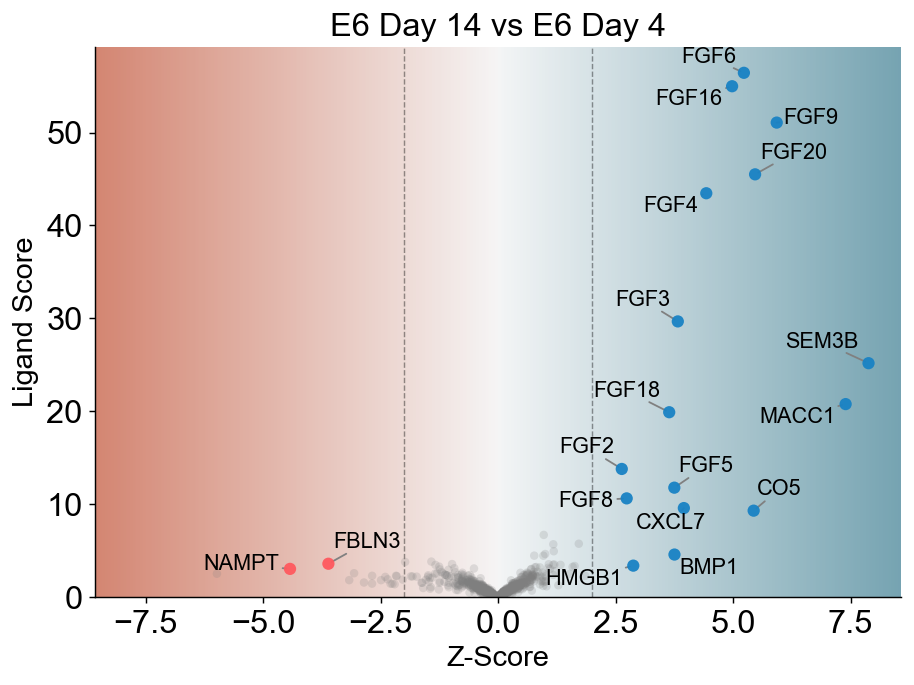

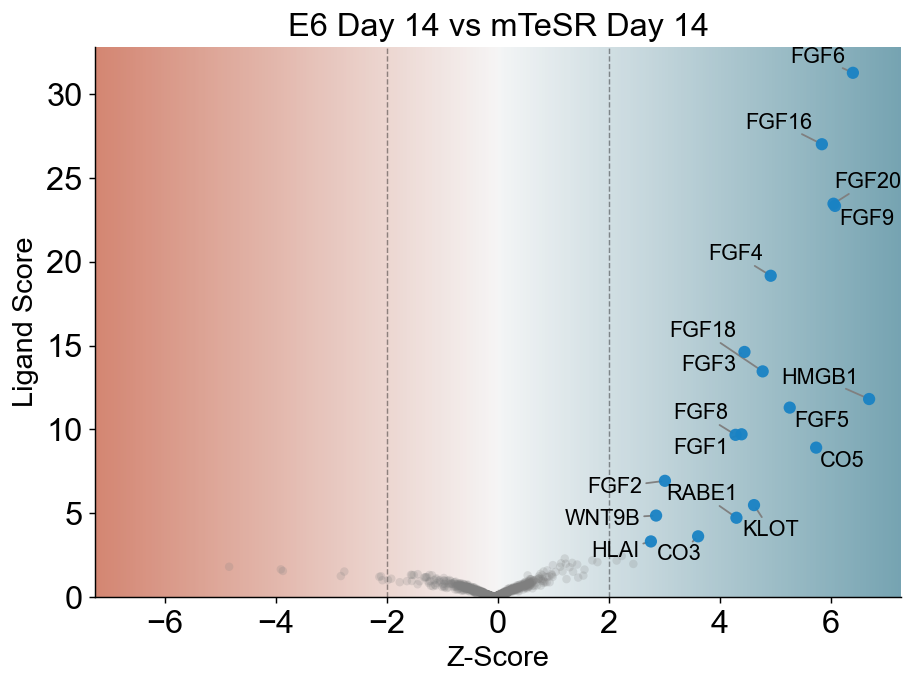

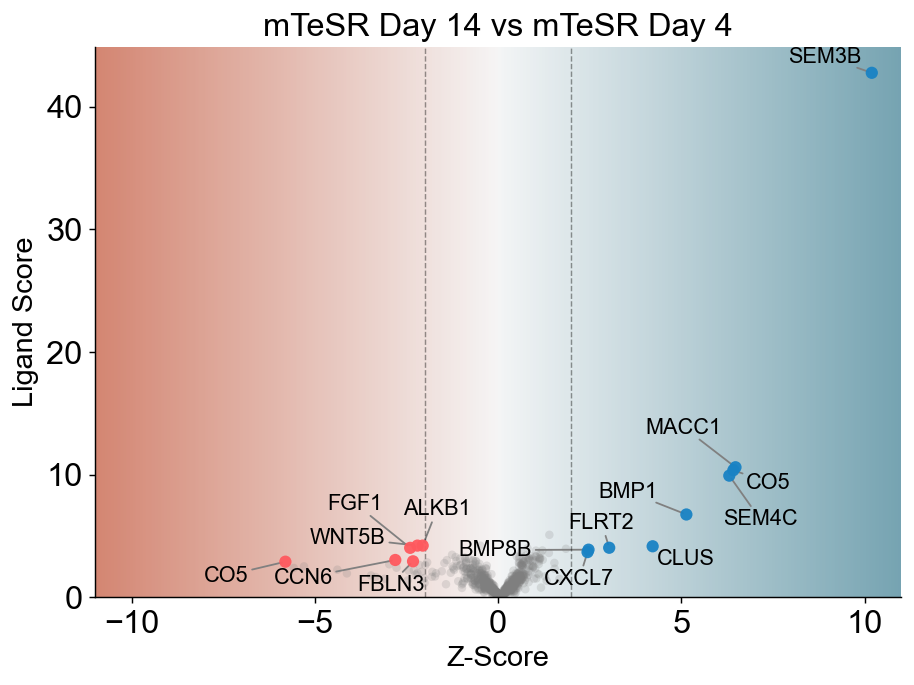

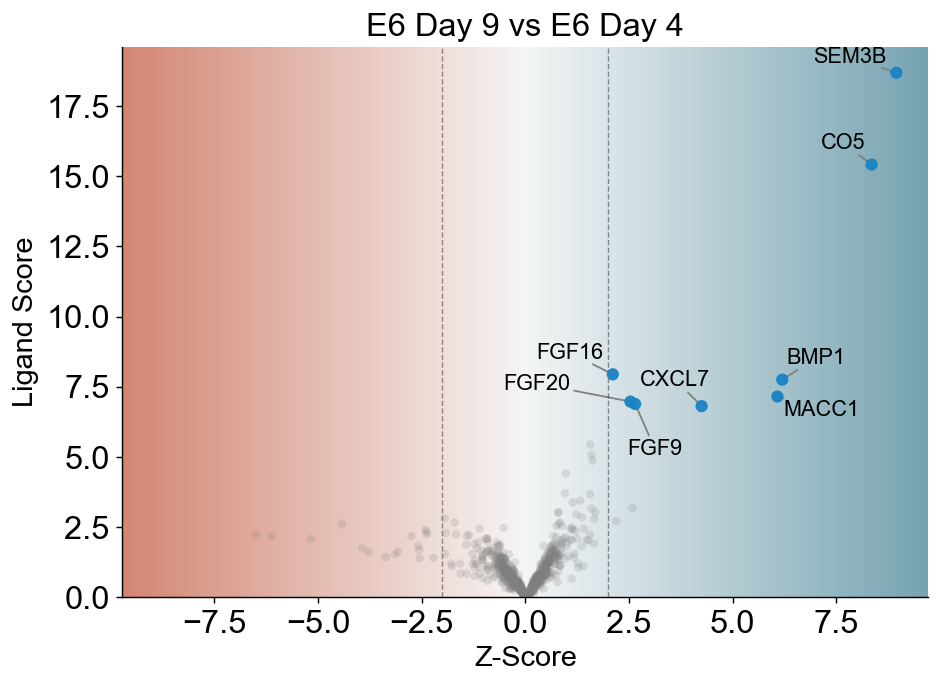

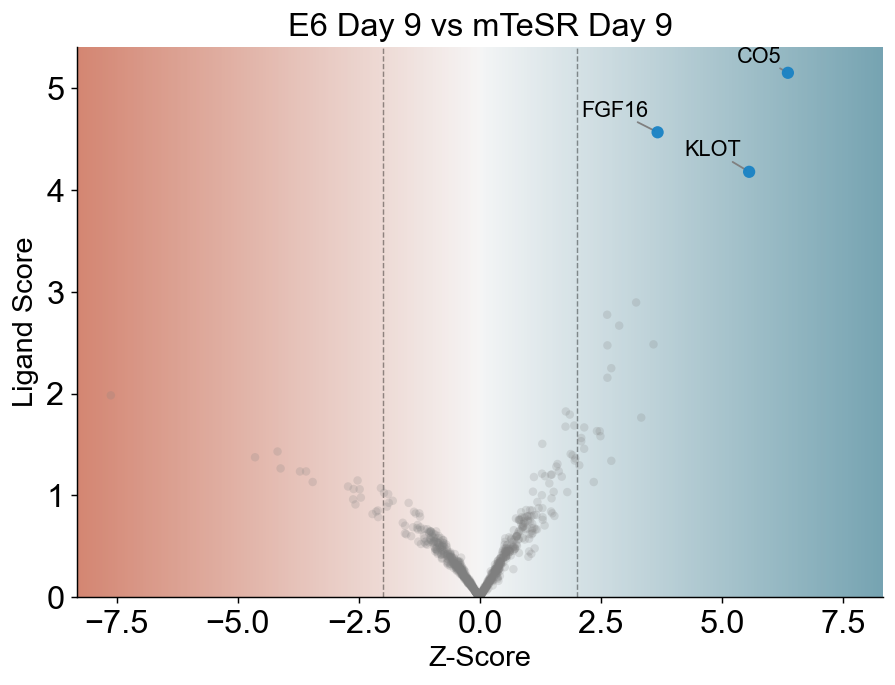

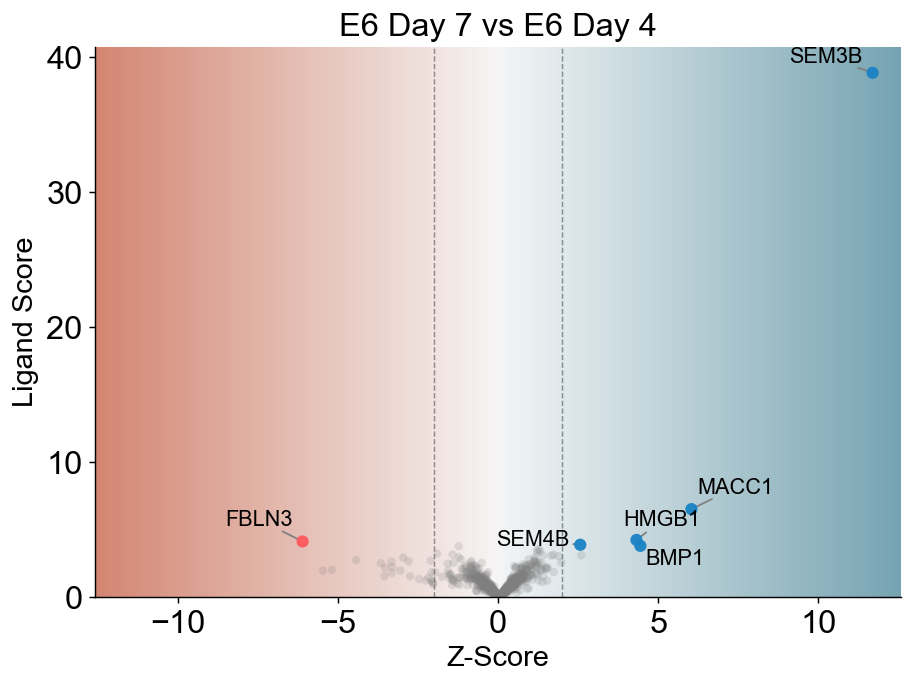

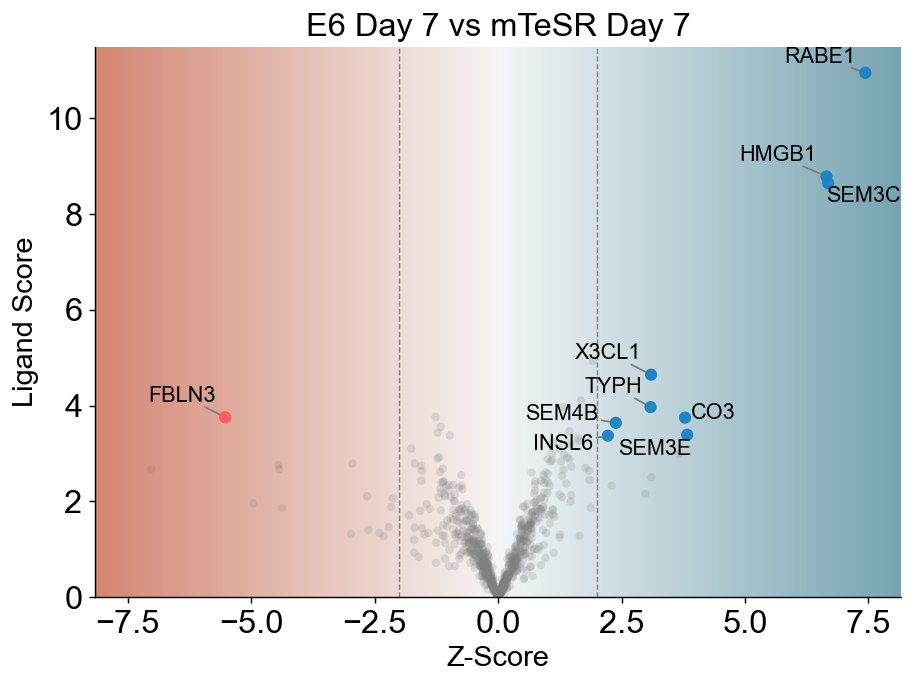

In [153]:
fig, _ = plot_lfc_vs_logscore(e6d14, title="E6 Day 14 vs E6 Day 4")
fig.savefig('/tscc/projects/ps-malilab/ydoctor/Ligandome_Screens/figures/E6_Day14_vs_E6_Day4.svg')
fig, _ = plot_lfc_vs_logscore(e6vsmtesrd14, title="E6 Day 14 vs mTeSR Day 14")
fig.savefig('/tscc/projects/ps-malilab/ydoctor/Ligandome_Screens/figures/E6_Day14_vs_mTeSR_Day14.svg')
fig, _ = plot_lfc_vs_logscore(mtesrd14, title="mTeSR Day 14 vs mTeSR Day 4")
fig.savefig('/tscc/projects/ps-malilab/ydoctor/Ligandome_Screens/figures/mTeSR_Day14_vs_mTeSR_Day4.svg')
fig, _ = plot_lfc_vs_logscore(e6d9, title="E6 Day 9 vs E6 Day 4")
fig.savefig('/tscc/projects/ps-malilab/ydoctor/Ligandome_Screens/figures/E6_Day9_vs_E6_Day4.svg')
fig, _ = plot_lfc_vs_logscore(e6vsmtesrd9, title="E6 Day 9 vs mTeSR Day 9")
fig.savefig('/tscc/projects/ps-malilab/ydoctor/Ligandome_Screens/figures/E6_Day9_vs_mTeSR_Day9.svg')
fig, _ = plot_lfc_vs_logscore(e6d7, title="E6 Day 7 vs E6 Day 4")
fig.savefig('/tscc/projects/ps-malilab/ydoctor/Ligandome_Screens/figures/E6_Day7_vs_E6_Day4.svg')
fig, _ = plot_lfc_vs_logscore(e6vsmtesrd7, title="E6 Day 7 vs mTeSR Day 7")
fig.savefig('/tscc/projects/ps-malilab/ydoctor/Ligandome_Screens/figures/E6_Day7_vs_mTeSR_Day7.svg')

In [6]:
import pandas as pd
xls = pd.ExcelFile('/tscc/projects/ps-malilab/ydoctor/Ligandome_Screens/Fitness_Screen_Analysis/ALL_vs_NGSplasmid.sgrna_summary.xlsx')
sheets = {sheet: xls.parse(sheet) for sheet in xls.sheet_names}
Day4vsNGS = sheets['Day4_vs_NGSplasmid.sgrna_summar']
Day7E6vsNGS = sheets['Day7_E6_vs_NGSplasmid.sgrna_sum']
Day7mTeSRvsNGS = sheets['Day7_mTeSR_vs_NGSplasmid.sgrna_']
Day9E6vsNGS = sheets['Day9_E6_vs_NGSplasmid.sgrna_sum']
Day9mTeSRvsNGS = sheets['Day9_mTeSR_vs_NGSplasmid.sgrna_']
Day14E6vsNGS = sheets['Day14_E6_vs_NGSplasmid.sgrna_su']
Day14mTeSRvsNGS = sheets['Day14_mTeSR_vs_NGSplasmid.sgrna']
Day4vsNGS['LFC_zscore'] = (Day4vsNGS['LFC'] - np.mean(Day4vsNGS['LFC'])) / np.std(Day4vsNGS['LFC'])
Day7E6vsNGS['LFC_zscore'] = (Day7E6vsNGS['LFC'] - np.mean(Day7E6vsNGS['LFC'])) / np.std(Day7E6vsNGS['LFC'])
Day7mTeSRvsNGS['LFC_zscore'] = (Day7mTeSRvsNGS['LFC'] - np.mean(Day7mTeSRvsNGS['LFC'])) / np.std(Day7mTeSRvsNGS['LFC'])
Day9E6vsNGS['LFC_zscore'] = (Day9E6vsNGS['LFC'] - np.mean(Day9E6vsNGS['LFC'])) / np.std(Day9E6vsNGS['LFC'])
Day9mTeSRvsNGS['LFC_zscore'] = (Day9mTeSRvsNGS['LFC'] - np.mean(Day9mTeSRvsNGS['LFC'])) / np.std(Day9mTeSRvsNGS['LFC'])
Day14E6vsNGS['LFC_zscore'] = (Day14E6vsNGS['LFC'] - np.mean(Day14E6vsNGS['LFC'])) / np.std(Day14E6vsNGS['LFC'])
Day14mTeSRvsNGS['LFC_zscore'] = (Day14mTeSRvsNGS['LFC'] - np.mean(Day14mTeSRvsNGS['LFC'])) / np.std(Day14mTeSRvsNGS['LFC'])

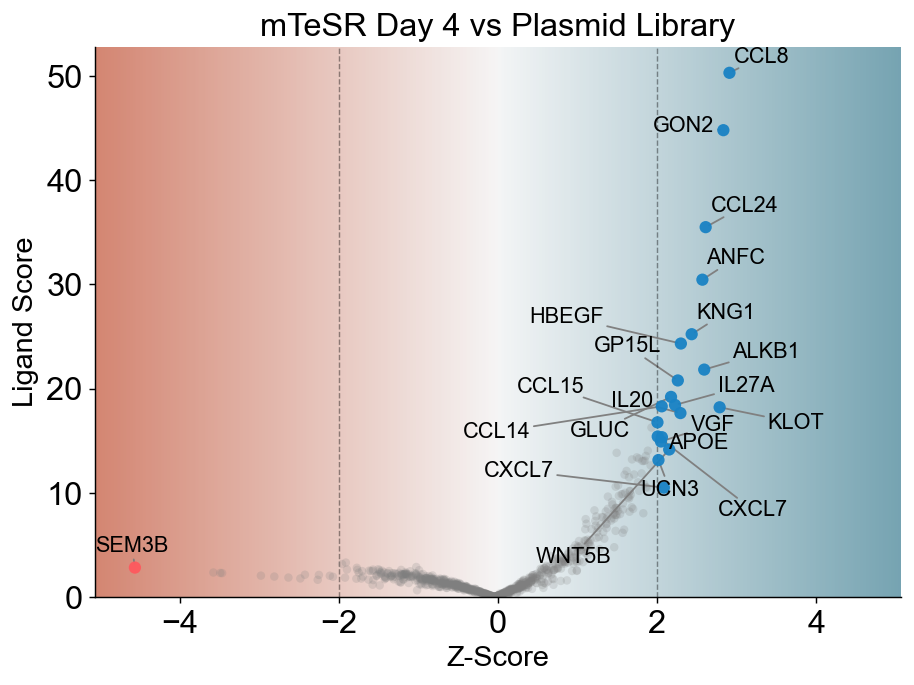

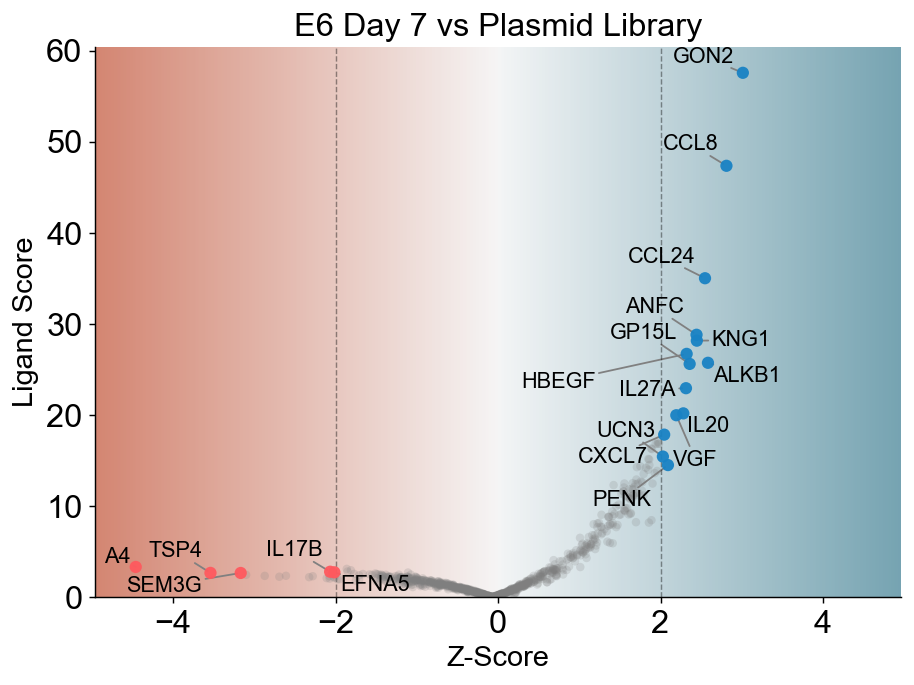

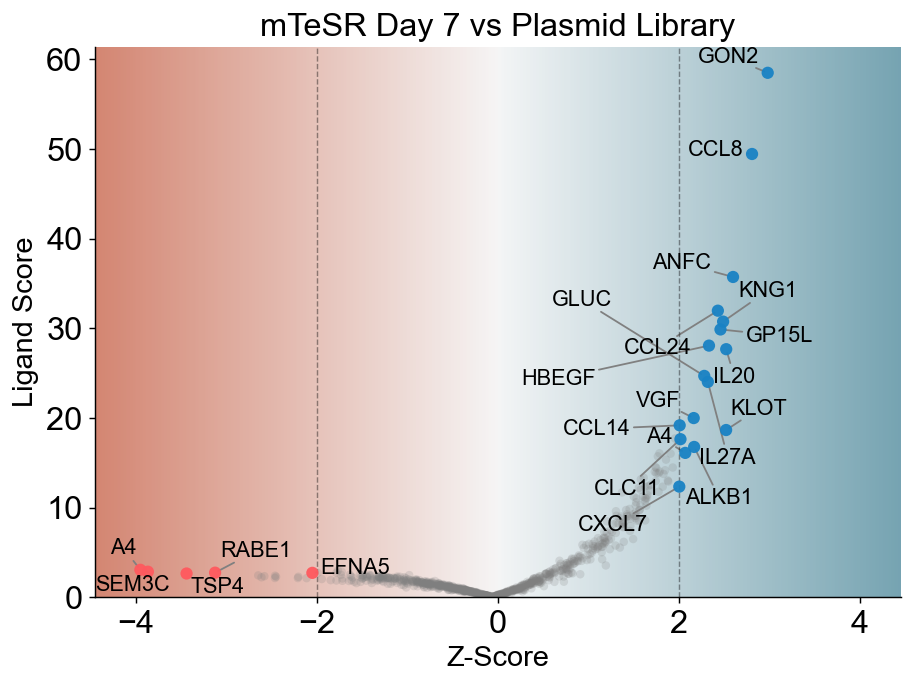

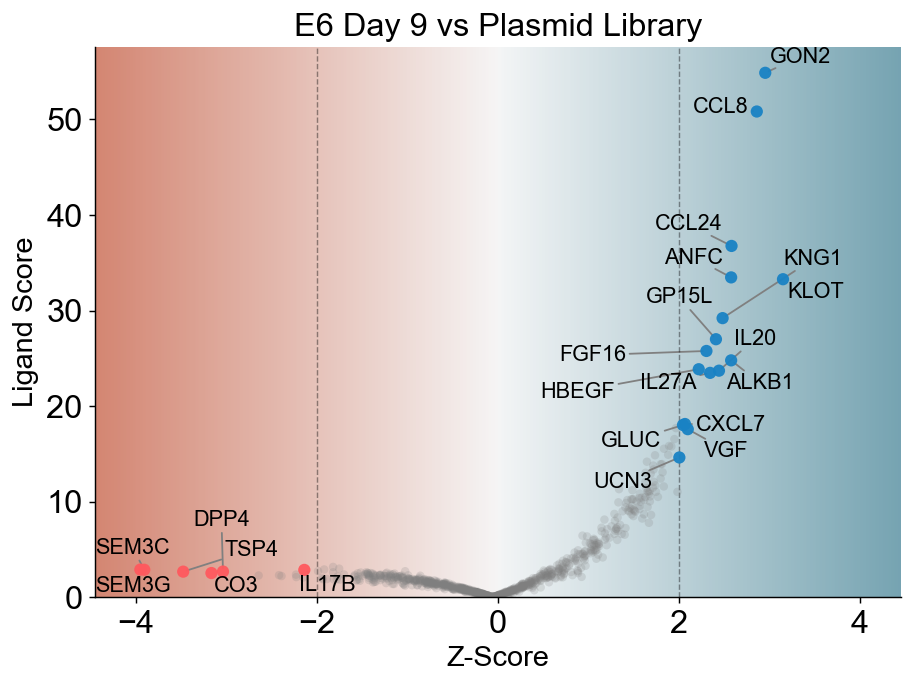

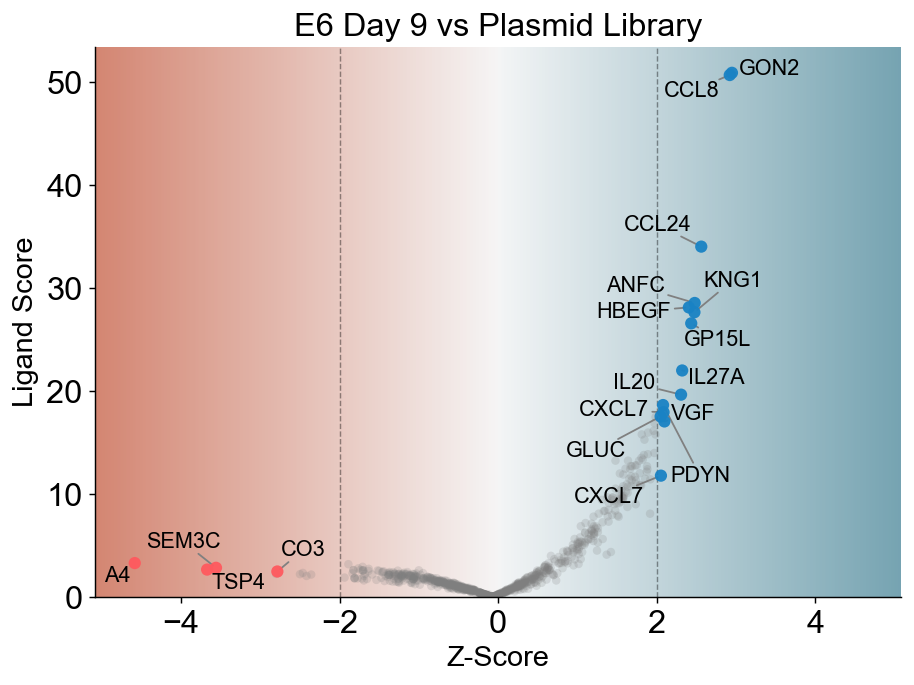

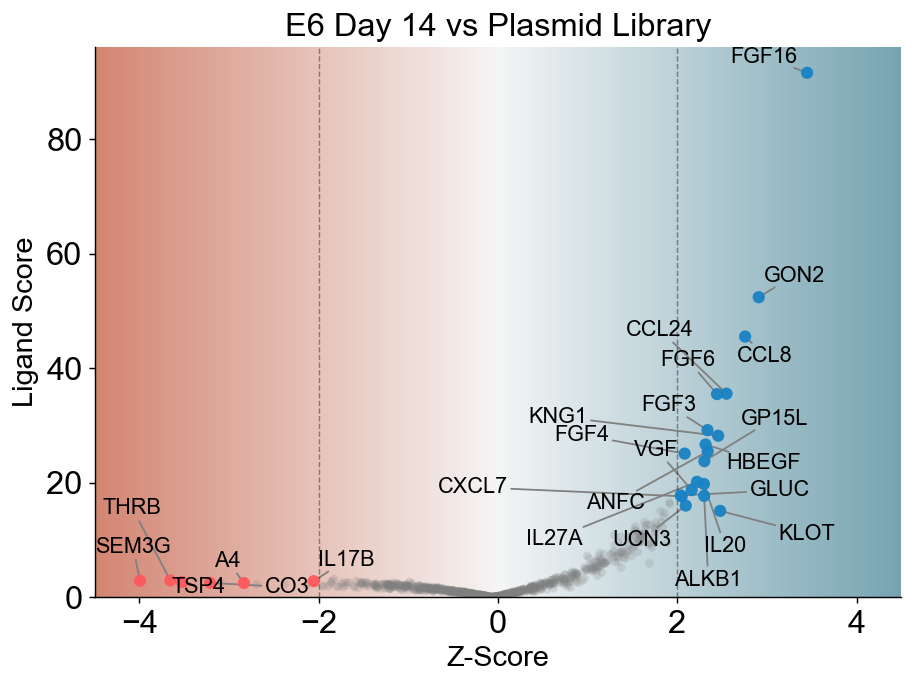

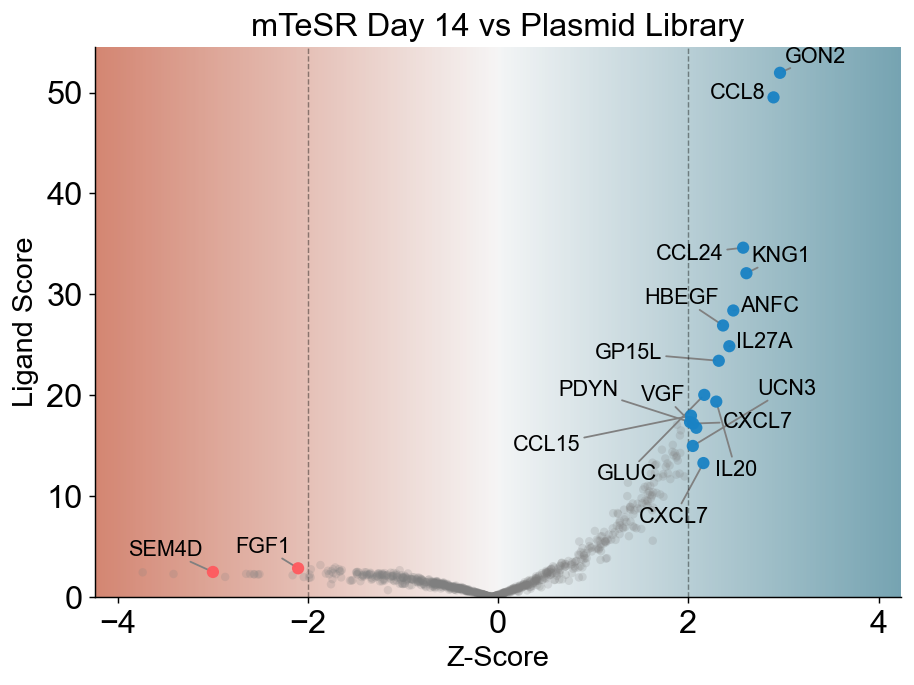

In [8]:
fig, _ = plot_lfc_vs_logscore(Day4vsNGS, title="mTeSR Day 4 vs Plasmid Library")
fig.savefig('/tscc/projects/ps-malilab/ydoctor/Ligandome_Screens/figures/mTeSR_Day4_vs_Plasmid_Library.svg')
fig, _ = plot_lfc_vs_logscore(Day7E6vsNGS, title="E6 Day 7 vs Plasmid Library")
fig.savefig('/tscc/projects/ps-malilab/ydoctor/Ligandome_Screens/figures/E6_Day7_vs_Plasmid_Library.svg')
fig, _ = plot_lfc_vs_logscore(Day7mTeSRvsNGS, title="mTeSR Day 7 vs Plasmid Library")
fig.savefig('/tscc/projects/ps-malilab/ydoctor/Ligandome_Screens/figures/mTeSR_Day7_vs_Plasmid_Library.svg')
fig, _ = plot_lfc_vs_logscore(Day9E6vsNGS, title="E6 Day 9 vs Plasmid Library")
fig.savefig('/tscc/projects/ps-malilab/ydoctor/Ligandome_Screens/figures/E6_Day9_vs_Plasmid_Library.svg')
fig, _ = plot_lfc_vs_logscore(Day9mTeSRvsNGS, title="E6 Day 9 vs Plasmid Library")
fig.savefig('/tscc/projects/ps-malilab/ydoctor/Ligandome_Screens/figures/E6_Day9_vs_Plasmid_Library.svg')
fig, _ = plot_lfc_vs_logscore(Day14E6vsNGS, title="E6 Day 14 vs Plasmid Library")
fig.savefig('/tscc/projects/ps-malilab/ydoctor/Ligandome_Screens/figures/E6_Day14_vs_Plasmid_Library.svg')
fig, _ = plot_lfc_vs_logscore(Day14mTeSRvsNGS, title="mTeSR Day 14 vs Plasmid Library")
fig.savefig('/tscc/projects/ps-malilab/ydoctor/Ligandome_Screens/figures/mTeSR_Day14_vs_Plasmid_Library.svg')

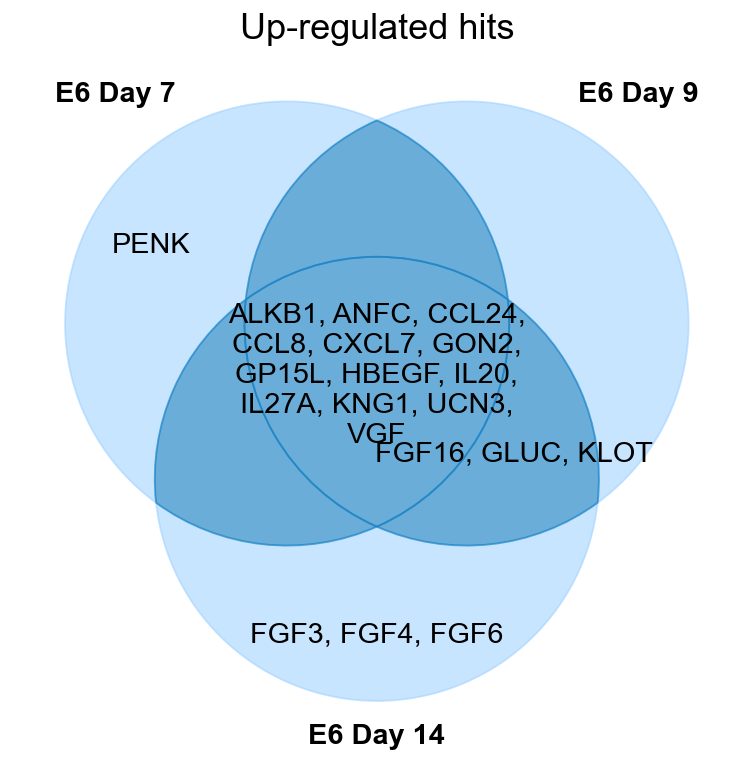

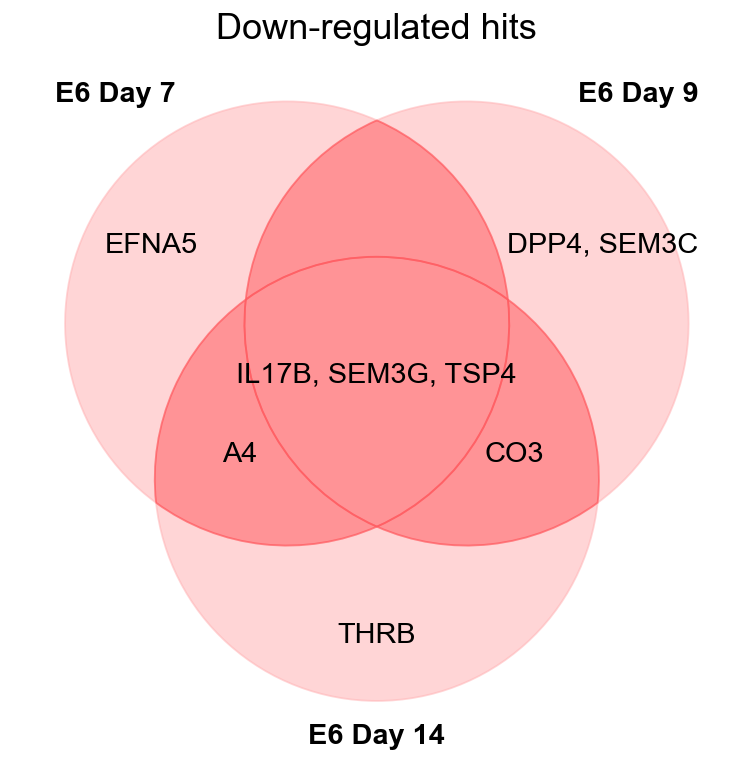

In [20]:
# Example: Venn diagrams for up/down hits between two conditions
# (edit the inputs/labels as needed)

fig_up, ax_up, fig_down, ax_down, hits = plot_up_down_venn(
    {  
        "E6 Day 7": Day7E6vsNGS,
        "E6 Day 9": Day9E6vsNGS,
        "E6 Day 14": Day14E6vsNGS,
    },
    title="",
    max_genes_per_region=14,  # increase/decrease depending on how dense you want the labels
    subset_fontsize=16,
    wrap_width=20,            # wraps comma-separated genes across multiple lines
    unweighted=True,          # more stable Venn geometry (areas not scaled)
    suppress_layout_warning=True,
)

fig_up.savefig('/tscc/projects/ps-malilab/ydoctor/Ligandome_Screens/figures/E6_UP_Hit_overlap.svg')
fig_down.savefig('/tscc/projects/ps-malilab/ydoctor/Ligandome_Screens/figures/E6_DOWN_Hit_overlap.svg')

plt.show()

# hits["up"] and hits["down"] contain the underlying gene sets for each label
# e.g. print(sorted(hits["up"]["E6 Day 14 vs Plasmid"]))


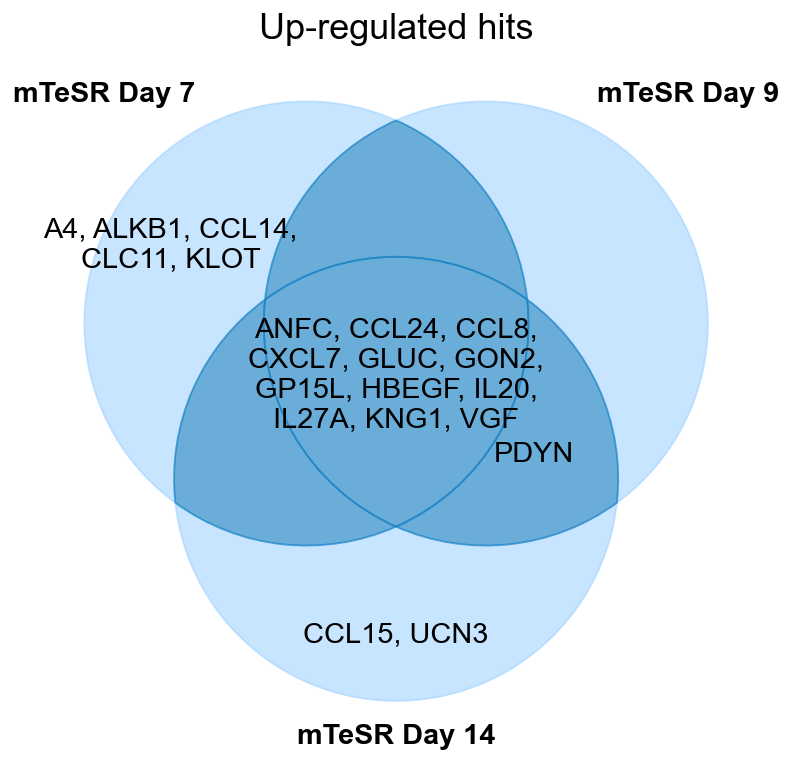

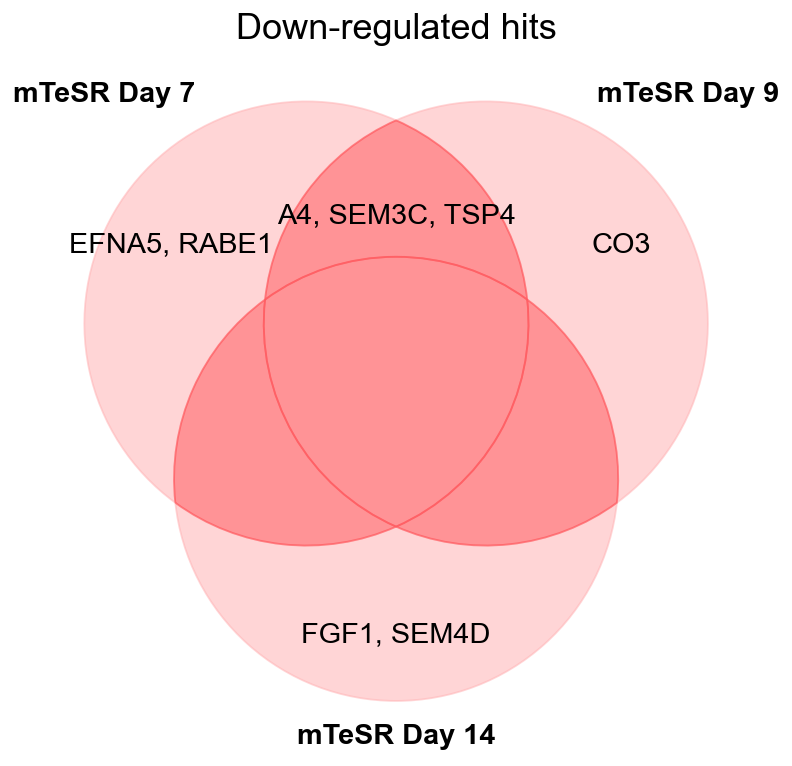

In [22]:
# Example: Venn diagrams for up/down hits between two conditions
# (edit the inputs/labels as needed)

fig_up, ax_up, fig_down, ax_down, hits = plot_up_down_venn(
    {  
        "mTeSR Day 7": Day7mTeSRvsNGS,
        "mTeSR Day 9": Day9mTeSRvsNGS,
        "mTeSR Day 14": Day14mTeSRvsNGS,
    },
    title="",
    max_genes_per_region=14,  # increase/decrease depending on how dense you want the labels
    subset_fontsize=16,
    wrap_width=20,            # wraps comma-separated genes across multiple lines
    unweighted=True,          # more stable Venn geometry (areas not scaled)
    suppress_layout_warning=True,
)

fig_up.savefig('/tscc/projects/ps-malilab/ydoctor/Ligandome_Screens/figures/mTeSR_UP_Hit_overlap.svg')
fig_down.savefig('/tscc/projects/ps-malilab/ydoctor/Ligandome_Screens/figures/mTeSR_DOWN_Hit_overlap.svg')

plt.show()

# hits["up"] and hits["down"] contain the underlying gene sets for each label
# e.g. print(sorted(hits["up"]["E6 Day 14 vs Plasmid"]))


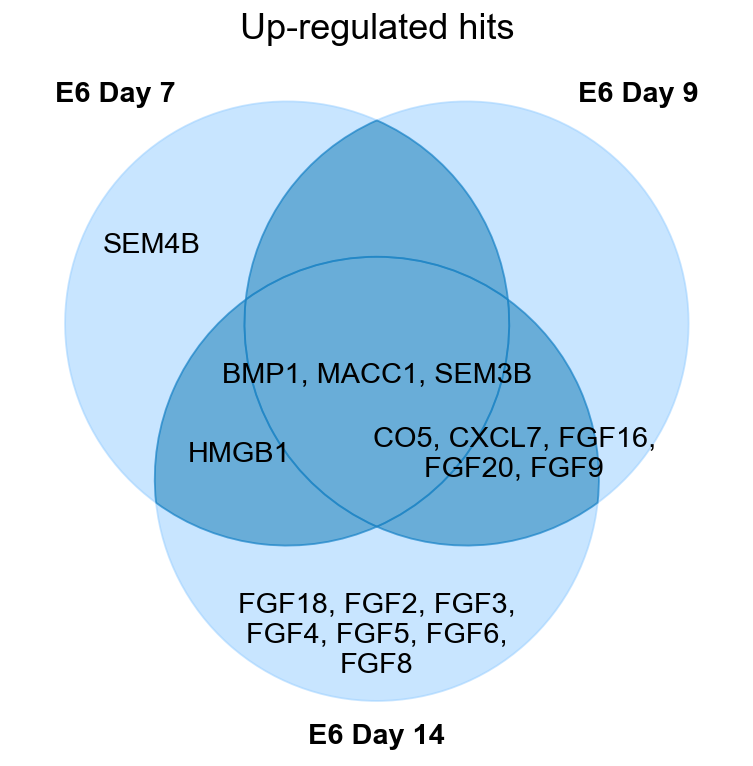

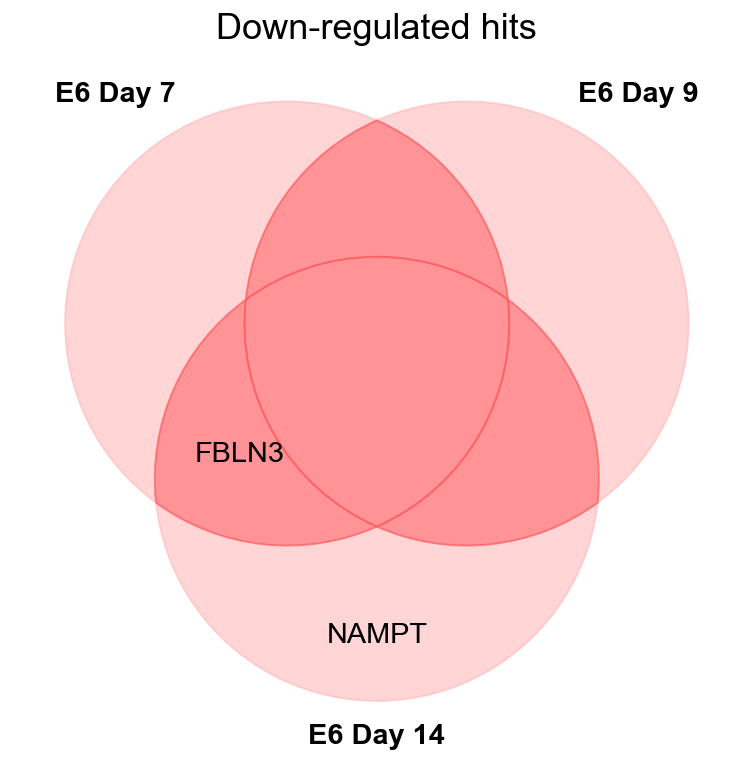

In [27]:
e6d14 = sheets['Day14_E6_vs_Day4_median.sgrna_s']
e6vsmtesrd14 = sheets['Day14_E6_vs_Day14_mTeSR.sgrna_s']
mtesrd14 = sheets['Day14_mTeSR_vs_Day4.sgrna_summa']
e6d9 = sheets['Day9_E6_vs_Day4.sgrna_summary_f']
e6vsmtesrd9 = sheets['Day9_E6_vs_Day9_mTeSR.sgrna_sum']
e6d7 = sheets['Day7_E6_vs_Day4 filtered.sgrna_']
e6vsmtesrd7 = sheets['Day7_E6_vs_Day7_mTeSR filtered.']

fig_up, ax_up, fig_down, ax_down, hits = plot_up_down_venn(
    {  
        "E6 Day 7": e6d7,
        "E6 Day 9": e6d9,
        "E6 Day 14": e6d14,
    },
    title="",
    max_genes_per_region=14,  # increase/decrease depending on how dense you want the labels
    subset_fontsize=16,
    wrap_width=20,            # wraps comma-separated genes across multiple lines
    unweighted=True,          # more stable Venn geometry (areas not scaled)
    suppress_layout_warning=True,
)

fig_up.savefig('/tscc/projects/ps-malilab/ydoctor/Ligandome_Screens/figures/E6_UP_Hit_Day4_Relative_overlap.svg')
fig_down.savefig('/tscc/projects/ps-malilab/ydoctor/Ligandome_Screens/figures/E6_DOWN_Hit_Day4_Relative_overlap.svg')

plt.show()

In [2]:
FGF_hits = (
    e6vsmtesrd14[
        (e6vsmtesrd14['FDR'] < 0.05) &
        (e6vsmtesrd14['LFC_zscore'] > 2) &
        (e6vsmtesrd14['Gene'].str.contains("FGF"))
    ]
    .sort_values(by='score', ascending=False)
)

genes = FGF_hits.Gene.tolist()

# Extract LFC for the selected genes in E6 day 7, 9, and 14 conditions
lfc_e6d7 = e6vsmtesrd7.set_index('Gene').loc[genes, 'LFC']
lfc_e6d9 = e6vsmtesrd9.set_index('Gene').loc[genes, 'LFC']
lfc_e6d14 = e6vsmtesrd14.set_index('Gene').loc[genes, 'LFC']

# Bundle together in a DataFrame for easy viewing
import pandas as pd
lfc_df = pd.DataFrame({
    "Gene": genes,
    "E6_Day7_LFC": lfc_e6d7.values,
    "E6_Day9_LFC": lfc_e6d9.values,
    "E6_Day14_LFC": lfc_e6d14.values
})

In [3]:
controls_genes = ['AMPR','CLUC','GLUC','HALO','MCHERRY','SNAP']

# Build LFC time course for control genes
# Some genes may have multiple sgRNAs; average LFC per gene.
control_lfc_e6d7 = (
    e6vsmtesrd7[e6vsmtesrd7['Gene'].isin(controls_genes)]
    .groupby('Gene')['LFC']
    .mean()
)
control_lfc_e6d9 = (
    e6vsmtesrd9[e6vsmtesrd9['Gene'].isin(controls_genes)]
    .groupby('Gene')['LFC']
    .mean()
)
control_lfc_e6d14 = (
    e6vsmtesrd14[e6vsmtesrd14['Gene'].isin(controls_genes)]
    .groupby('Gene')['LFC']
    .mean()
)

# Align by gene and ensure same length/ordering across days
control_lfc_df = pd.DataFrame(
    {
        "E6_Day7_LFC": control_lfc_e6d7.reindex(controls_genes),
        "E6_Day9_LFC": control_lfc_e6d9.reindex(controls_genes),
        "E6_Day14_LFC": control_lfc_e6d14.reindex(controls_genes),
    },
    index=controls_genes,
)


/scratch/ydoctor/job_8717271/ipykernel_3260046/4030816332.py:43: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_colors = plt.cm.get_cmap(colormap)


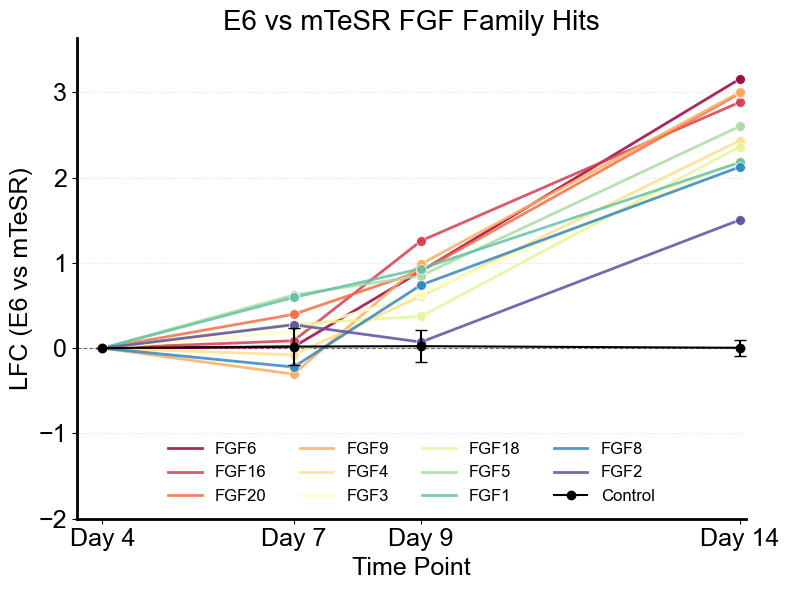

In [ ]:
def plot_lfc_timecourse(
    lfc_df,
    gene_col: str = "Gene",
    day_cols: dict = None,  # e.g., {7: "E6_Day7_LFC", 9: "E6_Day9_LFC", 14: "E6_Day14_LFC"}
    ax=None,
    title: str | None = None,
    colormap: str = "tab10",
    control_lfc_df=None,
):
    """
    Time course plot of LFC values across days.
    Day 4 is assumed to be 0 (baseline).

    Parameters
    ----------
    lfc_df : DataFrame with gene names and LFC columns for each day
    gene_col : column name for gene names
    day_cols : dict mapping day number to column name
    control_lfc_df : optional DataFrame of control genes with same columns as lfc_df,
                     used to plot the mean ± SD trajectory of controls.
    """
    mpl.rcParams["font.family"] = "Arial"

    if day_cols is None:
        day_cols = {7: "E6_Day7_LFC", 9: "E6_Day9_LFC", 14: "E6_Day14_LFC"}

    # Time points including Day 4 as baseline
    days = [4] + sorted(day_cols.keys())

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    else:
        fig = ax.figure

    # Remove background (no gradient)
    y_min, y_max = -2, lfc_df[[v for v in day_cols.values()]].max().max() * 1.15
    y_min = min(y_min, lfc_df[[v for v in day_cols.values()]].min().min() * 1.15)
    # Background is omitted as per user request

    # Get colors for each gene
    genes = lfc_df[gene_col].tolist()
    n_genes = len(genes)
    cmap_colors = plt.cm.get_cmap(colormap)
    colors = [cmap_colors(i / max(n_genes - 1, 1)) for i in range(n_genes)]

    # Plot each gene's trajectory and collect handles for legend
    legend_handles = []

    for i, (idx, row) in enumerate(lfc_df.iterrows()):
        gene = row[gene_col]
        # Build LFC values: Day 4 = 0, then actual values
        lfcs = [0.0] + [row[day_cols[d]] for d in sorted(day_cols.keys())]

        # Plot line and store handle for legend
        line, = ax.plot(
            days,
            lfcs,
            color=colors[i],
            linewidth=2,
            alpha=0.85,
            zorder=2,
            label=gene,
        )
        legend_handles.append(line)
        # Plot points
        ax.scatter(
            days,
            lfcs,
            color=colors[i],
            s=50,
            alpha=0.95,
            edgecolors="white",
            linewidths=0.5,
            zorder=3,
        )

    # If control LFCs are provided, plot their mean ± SD across genes
    # as NTC dots with vertical error bars.
    control_handle = None
    if control_lfc_df is not None and not control_lfc_df.empty:
        # Extract just the day columns in sorted order
        control_values = control_lfc_df[[day_cols[d] for d in sorted(day_cols.keys())]]
        control_means = control_values.mean(axis=0).to_list()
        control_stds = control_values.std(axis=0).to_list()

        # Include Day 4 = 0 as baseline for controls as well
        control_means = [0.0] + control_means
        control_stds = [0.0] + control_stds

        control_means = np.array(control_means, dtype=float)
        control_stds = np.array(control_stds, dtype=float)

        # Plot NTCs as black dots connected by lines with error bars
        err = ax.errorbar(
            days,
            control_means,
            yerr=control_stds,
            fmt='-o',  # line + circle markers
            color='black',
            ecolor='black',
            elinewidth=1.5,
            capsize=4,
            markersize=6,
            zorder=4,
        )
        # Explicitly set legend label on the line object so it is not '_nolegend_'
        if hasattr(err, 'lines') and len(err.lines) > 0:
            err.lines[0].set_label('Control')
            control_handle = err.lines[0]
        else:
            control_handle = None

    # Horizontal line at 0
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.6, linestyle="--", zorder=1)

    # Axes formatting
    ax.set_xlim(days[0] - 0.4, days[-1] + 0.1)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(days)
    ax.set_xticklabels([f"Day {d}" for d in days])

    ax.set_xlabel("Time Point", fontsize=18)
    ax.set_ylabel("LFC (E6 vs mTeSR)", fontsize=18)
    if title:
        ax.set_title(title, fontsize=20)
    ax.tick_params(labelsize=18)

    # Make x and y axes (spines) thicker
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)

    # Add subtle grid
    ax.yaxis.grid(True, linestyle=':', alpha=0.4, zorder=1)

    # Remove top and right spines (borders)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    # Build legend handles including controls if present
    legend_all_handles = legend_handles.copy()
    if control_handle is not None:
        legend_all_handles.append(control_handle)

    # Legend in 2 rows by 4 columns, with NTCs as the last entry
    ax.legend(
        handles=legend_all_handles,
        loc="lower center",
        ncol=4,
        frameon=False,
        fontsize=12,
    )

    return fig, ax


# Plot the time course
fig, ax = plot_lfc_timecourse(
    lfc_df, 
    title="E6 vs mTeSR FGF Family Hits",
    colormap='Spectral',
    control_lfc_df=control_lfc_df,
)
plt.tight_layout()
fig.savefig('/tscc/projects/ps-malilab/ydoctor/Ligandome_Screens/figures/E6_vs_mTeSR_FGF_Family_Hits.svg')
plt.show()


Per-day LFC summary (FGF Hits vs Control):


,Day,Group,mean,std,n
0,7,Control,0.018666,0.215071,6
1,7,FGF Hits,0.169680,0.305217,11
2,9,Control,0.023389,0.184832,6
3,9,FGF Hits,0.752244,0.322508,11
4,14,Control,0.004485,0.091189,6
5,14,FGF Hits,2.494945,0.492460,11



Per-day FGF Hits vs Control Welch t-tests:


,Day,FGF Hits_mean,FGF Hits_std,FGF Hits_n,Control_mean,Control_std,Control_n,t_stat,p_val
0,7,0.169680,0.305217,11,0.018666,0.215071,6,1.187281,2.552482e-01
1,9,0.752244,0.322508,11,0.023389,0.184832,6,5.921644,2.898905e-05
2,14,2.494945,0.492460,11,0.004485,0.091189,6,16.269216,3.790196e-09



Two-way ANOVA (Group, Day, Group×Day):


,sum_sq,df,F,PR(>F)
C(Group),14.700034,1.0,136.658968,3.131408e-15
C(Day),20.675611,2.0,96.105480,5.711493e-17
C(Group):C(Day),11.530803,2.0,53.598094,1.239357e-12
Residual,4.840528,45.0,NaN,NaN


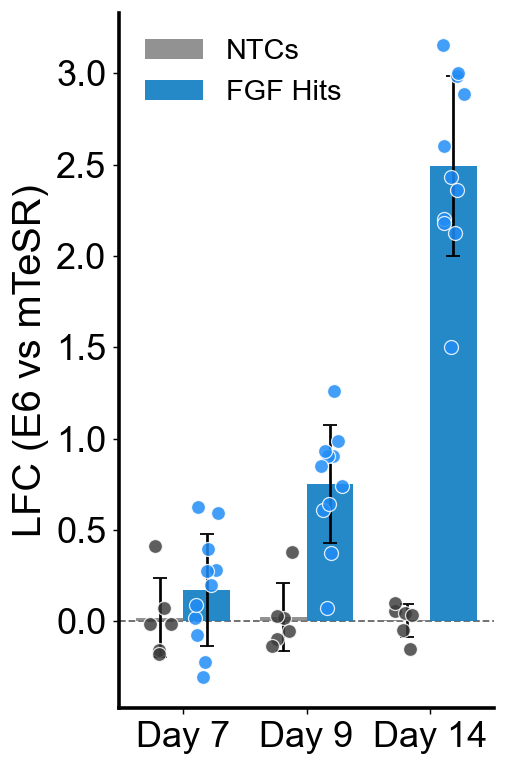

In [25]:
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import matplotlib as mpl

# Compare FGF Hits vs control LFCs across time using two-way ANOVA (Group × Day)
# and report per-day means, standard deviations, sample sizes, and per-day p-values.

day_cols = {7: "E6_Day7_LFC", 9: "E6_Day9_LFC", 14: "E6_Day14_LFC"}

# Build long-form data for FGF Hits genes
value_cols = [day_cols[d] for d in sorted(day_cols.keys())]
fgf_long = (
    lfc_df[["Gene"] + value_cols]
    .melt(id_vars=["Gene"], value_vars=value_cols, var_name="DayCol", value_name="LFC")
)
col_to_day = {v: d for d, v in day_cols.items()}
fgf_long["Day"] = fgf_long["DayCol"].map(col_to_day)
fgf_long["Group"] = "FGF Hits"

# Build long-form data for control genes
ctrl_df = control_lfc_df.copy()
if "Gene" not in ctrl_df.columns:
    ctrl_df = ctrl_df.copy()
    ctrl_df["Gene"] = ctrl_df.index
ctrl_long = (
    ctrl_df[["Gene"] + value_cols]
    .melt(id_vars=["Gene"], value_vars=value_cols, var_name="DayCol", value_name="LFC")
)
ctrl_long["Day"] = ctrl_long["DayCol"].map(col_to_day)
ctrl_long["Group"] = "Control"

# Combine, drop missing LFCs
long_df = (
    pd.concat([fgf_long[["Gene", "Day", "LFC", "Group"]],
               ctrl_long[["Gene", "Day", "LFC", "Group"]]], ignore_index=True)
    .dropna(subset=["LFC", "Day"])
)

# Per-day summary statistics (mean, std, n) for each group
summary = (
    long_df
    .groupby(["Day", "Group"], as_index=False)["LFC"]
    .agg(mean="mean", std="std", n="size")
    .sort_values(["Day", "Group"])
)

# Per-day FGF Hits vs Control Welch t-tests (post-hoc comparisons)
per_day_tests = []
for day in sorted(day_cols.keys()):
    sub = long_df[long_df["Day"] == day]
    fgf_vals = sub.loc[sub["Group"] == "FGF Hits", "LFC"].to_numpy()
    ctrl_vals = sub.loc[sub["Group"] == "Control", "LFC"].to_numpy()
    if fgf_vals.size > 0 and ctrl_vals.size > 0:
        t_stat, p_val = ttest_ind(fgf_vals, ctrl_vals, equal_var=False)
    else:
        t_stat, p_val = np.nan, np.nan
    per_day_tests.append({
        "Day": day,
        "FGF Hits_mean": float(np.mean(fgf_vals)) if fgf_vals.size > 0 else np.nan,
        "FGF Hits_std": float(np.std(fgf_vals, ddof=1)) if fgf_vals.size > 1 else np.nan,
        "FGF Hits_n": int(fgf_vals.size),
        "Control_mean": float(np.mean(ctrl_vals)) if ctrl_vals.size > 0 else np.nan,
        "Control_std": float(np.std(ctrl_vals, ddof=1)) if ctrl_vals.size > 1 else np.nan,
        "Control_n": int(ctrl_vals.size),
        "t_stat": float(t_stat) if np.isfinite(t_stat) else np.nan,
        "p_val": float(p_val) if np.isfinite(p_val) else np.nan,
    })
per_day_tests_df = pd.DataFrame(per_day_tests)

# Two-way ANOVA: factors Group (FGF Hits vs Control) and Day
anova_df = long_df.copy()
anova_df["Group"] = anova_df["Group"].astype("category")
anova_df["Day"] = anova_df["Day"].astype("category")
model = ols("LFC ~ C(Group) + C(Day) + C(Group):C(Day)", data=anova_df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

from IPython.display import display

print("Per-day LFC summary (FGF Hits vs Control):")
display(summary)
print("\nPer-day FGF Hits vs Control Welch t-tests:")
display(per_day_tests_df)
print("\nTwo-way ANOVA (Group, Day, Group×Day):")
display(anova_table)

# Bar plot of mean ± SD LFCs for FGF Hits vs Control at each time point
mpl.rcParams["font.family"] = "Arial"

days_sorted = sorted(day_cols.keys())
x = np.arange(len(days_sorted))
width = 0.38

# Helper to extract mean and SD series for each group in the correct day order
def _series_for(group_name: str):
    sub = summary[summary["Group"] == group_name].set_index("Day").reindex(days_sorted)
    return sub["mean"].to_numpy(), sub["std"].to_numpy()

fgf_mean, fgf_std = _series_for("FGF Hits")
ctrl_mean, ctrl_std = _series_for("Control")

fig, ax = plt.subplots(figsize=(4, 6), dpi=130)

bars_ctrl = ax.bar(
    x - width / 2,
    ctrl_mean,
    width=width,
    yerr=ctrl_std,
    capsize=4,
    color="#7f7f7f",
    alpha=0.85,
    label="NTCs",  # Changed from 'Control' to 'NTC'
    zorder=3,
)
bars_fgf = ax.bar(
    x + width / 2,
    fgf_mean,
    width=width,
    yerr=fgf_std,
    capsize=4,
    color="#1982C4",
    alpha=0.95,
    label="FGF Hits",
    zorder=3,
)

# --- Show individual dots as well ---
# Plot individual points (jittered) for each group and day
jitter_scale = 0.10  # you may adjust to tune how much jitter

for i, day in enumerate(days_sorted):
    # Control dots
    y_ctrl = long_df[(long_df["Day"] == day) & (long_df["Group"] == "Control")]["LFC"]
    x_ctrl_jittered = np.full_like(y_ctrl, x[i] - width / 2, dtype=float)
    if len(y_ctrl) > 0:
        x_ctrl_jittered += np.random.uniform(-jitter_scale, jitter_scale, size=len(y_ctrl))
        ax.scatter(
            x_ctrl_jittered,
            y_ctrl,
            color="#3a3a3a",
            edgecolor="white",
            lw=0.7,
            s=60,
            alpha=0.82,
            zorder=5,
            label=None,  # Remove NTC from dots so it doesn't go in the legend
        )
    # FGF Hits dots
    y_fgf = long_df[(long_df["Day"] == day) & (long_df["Group"] == "FGF Hits")]["LFC"]
    x_fgf_jittered = np.full_like(y_fgf, x[i] + width / 2, dtype=float)
    if len(y_fgf) > 0:
        x_fgf_jittered += np.random.uniform(-jitter_scale, jitter_scale, size=len(y_fgf))
        ax.scatter(
            x_fgf_jittered,
            y_fgf,
            color="#218df5",
            edgecolor="white",
            lw=0.7,
            s=60,
            alpha=0.85,
            zorder=5,
        )

# Baseline at 0
ax.axhline(0, color="black", linewidth=1.0, alpha=0.6, linestyle="--", zorder=1)

# Axes styling consistent with other plots
ax.set_xticks(x)
ax.set_xticklabels([f"Day {d}" for d in days_sorted], fontsize=20)
ax.set_ylabel("LFC (E6 vs mTeSR)", fontsize=22)
ax.tick_params(labelsize=20)

ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False, fontsize=16, loc="upper left")

plt.tight_layout()
fig.savefig('/tscc/projects/ps-malilab/ydoctor/Ligandome_Screens/figures/FGF_Hits_vs_NTCs_LFC_Barplot.svg')
plt.show()

Measuring the replicate correlation

In [5]:
import pandas as pd
data = pd.read_csv('/tscc/projects/ps-malilab/ydoctor/Ligandome_Screens/global_r1_vs_r2.csv')

In [6]:
data

,sgRNA,Gene,log2FC_Day4_mTeSR_r1_vs_plasmid,log2FC_Day4_mTeSR_r2_vs_plasmid,log2FC_Day7_E6_r1_vs_plasmid,log2FC_Day7_E6_r2_vs_plasmid,log2FC_Day7_mTeSR_r1_vs_plasmid,log2FC_Day7_mTeSR_r2_vs_plasmid,log2FC_Day9_E6_r1_vs_plasmid,log2FC_Day9_E6_r2_vs_plasmid,log2FC_Day9_mTeSR_r1_vs_plasmid,log2FC_Day9_mTeSR_r2_vs_plasmid,log2FC_Day14_E6_r1_vs_plasmid,log2FC_Day14_E6_r2_vs_plasmid,log2FC_Day14_mTeSR_r1_vs_plasmid,log2FC_Day14_mTeSR_r2_vs_plasmid
0,GS0001_A4_HUMAN,A4,-0.159584,0.146960,0.007290,0.025353,-0.129760,0.267243,-0.047307,0.209528,-0.260445,0.233313,-0.181530,-0.188968,-0.183882,-0.078864
1,GS0002_A4_HUMAN,A4,0.525006,0.517845,0.617387,0.460394,0.501895,0.715606,0.545477,0.188987,0.366329,0.499024,0.711468,0.262331,0.776162,0.540571
2,GS0003_A4_HUMAN,A4,-0.854229,-0.789566,-0.756671,-0.733404,-0.983370,-0.937986,-0.765393,-0.901746,-0.731728,-1.099864,-0.847916,-1.227969,-0.861554,-0.974198
3,GS0004_A4_HUMAN,A4,0.032737,0.336550,-1.061358,0.325353,0.592593,0.370683,-0.921438,0.555326,0.199067,-0.081757,-0.356557,-0.528089,-0.114984,-0.484040
4,GS0005_A4_HUMAN,A4,-1.961956,-6.680143,-6.680143,-5.537933,-4.801678,-6.680143,-3.142985,-3.191047,-5.505887,-6.680143,-3.035760,-5.668746,-2.420551,-2.928296
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
745,OG0276_CXL10_HUMAN,CXL10,-0.277374,-1.158460,-0.669115,-0.453196,-0.455381,-0.760606,-0.866828,-0.338319,-0.294902,-1.086121,-0.263647,-0.701703,-0.182421,-0.002022
746,OG0277_CXL11_HUMAN,CXL11,0.473332,0.337861,0.506264,0.033380,0.479473,0.799870,0.315103,0.341111,0.312526,0.570918,0.393175,0.253908,0.382822,0.539910
747,OG0278_GROA_HUMAN,GROA,-0.234970,-0.355950,-1.086726,-0.064745,-0.990676,-0.134902,-0.674461,-0.247706,-0.356377,-0.435075,-0.513870,-0.104721,-0.331599,-0.249622
748,OG0279_IL8_HUMAN,IL8,1.561483,1.601757,1.440520,1.423467,1.706629,1.653657,1.690994,1.198860,1.564481,1.614921,1.549184,1.112196,1.551679,1.979906


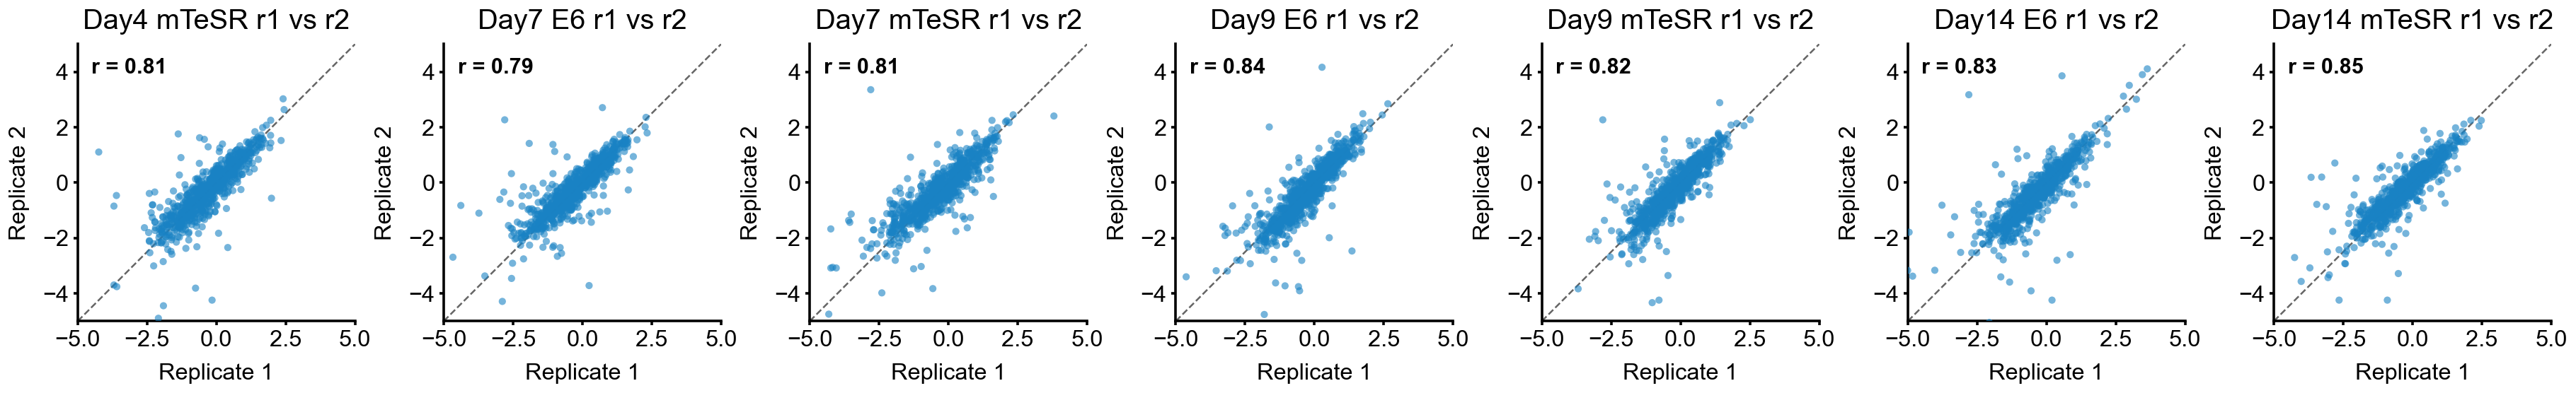

In [11]:
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import matplotlib as mpl


def plot_replicate_correlations(df, sgrna_col="sgRNA", gene_col="Gene"):
    """Plot replicate (r1 vs r2) correlations for every pair of value columns.

    Assumes that all columns except `sgrna_col` and `gene_col` come in r1/r2 pairs
    in order, e.g. [cond1_r1, cond1_r2, cond2_r1, cond2_r2, ...].
    Returns (fig, axes).
    """
    # Identify value columns (everything except ID columns)
    value_cols = [c for c in df.columns if c not in [sgrna_col, gene_col]]

    if len(value_cols) % 2 != 0:
        raise ValueError(
            f"Expected an even number of value columns, got {len(value_cols)}. "
            "Check that replicate columns are properly paired."
        )

    # Build r1/r2 column pairs in order
    pairs = [(value_cols[i], value_cols[i + 1]) for i in range(0, len(value_cols), 2)]
    n_pairs = len(pairs)

    # Match general style of other figures
    mpl.rcParams["font.family"] = "Arial"

    fig, axes = plt.subplots(
        1,
        n_pairs,
        figsize=(4 * n_pairs, 4),
        dpi=130,
        sharex=False,
        sharey=False,
    )

    # Ensure axes is always iterable
    if n_pairs == 1:
        axes = [axes]

    for ax, (c1, c2) in zip(axes, pairs):
        sub = df[[c1, c2]].dropna()
        x = sub[c1].to_numpy()
        y = sub[c2].to_numpy()

        if x.size == 0:
            ax.set_visible(False)
            continue

        # Scatter points
        ax.scatter(
            x,
            y,
            s=32,  # larger for visibility; was 22
            alpha=0.6,
            color="#1982C4",  # same blue as earlier scatter plots
            edgecolors="none",
            zorder=3,
        )

        # 1:1 reference line over the symmetric limits
        ax.plot([-5, 5], [-5, 5], color="black", linestyle="--", linewidth=1.4, alpha=0.6, zorder=2)
        ax.set_xlim(-5, 5)
        ax.set_ylim(-5, 5)
        ax.set_aspect("equal", "box")

        # Axes styling to match other plots
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_linewidth(2)
        ax.spines["bottom"].set_linewidth(2)
        ax.tick_params(labelsize=18, width=2)  # Larger tick labels and thicker ticks

        # Title from condition name (strip log2FC_ and replicate tag for readability)
        base = c1
        base = base.replace("log2FC_", "")
        base = base.replace("_r1_vs_plasmid", "")
        title = base.replace("_", " ")
        ax.set_title(title + " r1 vs r2", fontsize=22, pad=12)

        ax.set_xlabel("Replicate 1", fontsize=18, labelpad=10)
        ax.set_ylabel("Replicate 2", fontsize=18, labelpad=10)

        # Pearson correlation coefficient
        if x.size > 1:
            r = float(np.corrcoef(x, y)[0, 1])
        else:
            r = float("nan")
        if np.isfinite(r):
            ax.text(
                0.05,
                0.95,
                f"r = {r:.2f}",
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=17,  # Larger annotation font
                fontweight="bold"
            )

    plt.tight_layout()
    return fig, axes


# Plot all replicate correlations in a single row of scatter plots
fig, axes = plot_replicate_correlations(data)
plt.show()
fig.savefig('/tscc/projects/ps-malilab/ydoctor/Ligandome_Screens/figures/replicate_correlations.svg')
